In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tarkwa_monthly_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Create lag features — rainfall from 1, 2, and 3 months prior
df["Lag_1"] = df["Monthly_Rainfall_mm"].shift(1)
df["Lag_2"] = df["Monthly_Rainfall_mm"].shift(2)
df["Lag_3"] = df["Monthly_Rainfall_mm"].shift(3)

# The first 3 rows now have NaN lags (no prior months exist for them) — drop those
df_lagged = df.dropna().reset_index(drop=True)

print("Shape before dropping NaN lag rows:", df.shape)
print("Shape after:", df_lagged.shape)
print("\nFirst 5 rows of the lagged dataset:")
print(df_lagged[["Date", "Monthly_Rainfall_mm", "Lag_1", "Lag_2", "Lag_3", "Month_Num"]].head())

Shape before dropping NaN lag rows: (285, 8)
Shape after: (282, 8)

First 5 rows of the lagged dataset:
        Date  Monthly_Rainfall_mm  Lag_1  Lag_2  Lag_3  Month_Num
0 1996-04-01                242.3  106.4   96.5   10.8          4
1 1996-05-01                277.7  242.3  106.4   96.5          5
2 1996-06-01                323.9  277.7  242.3  106.4          6
3 1996-07-01                286.1  323.9  277.7  242.3          7
4 1996-08-01                174.1  286.1  323.9  277.7          8


In [2]:
from xgboost import XGBRegressor

feature_cols = ["Lag_1", "Lag_2", "Lag_3", "Month_Num"]
X = df_lagged[feature_cols].values
y = df_lagged["Monthly_Rainfall_mm"].values

# Find the split point by date, not by a hardcoded index — this guarantees
# the test period is exactly Jan 2015 onward regardless of how many rows got dropped
split_date = "2015-01-01"
split_idx = df_lagged[df_lagged["Date"] >= split_date].index[0]

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Split index: {split_idx}")
print(f"Train: {len(X_train)} rows, ending {df_lagged['Date'].iloc[split_idx-1].date()}")
print(f"Test:  {len(X_test)} rows, starting {df_lagged['Date'].iloc[split_idx].date()}")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

print("\nModel fitted successfully")
print("Feature importances:", dict(zip(feature_cols, xgb_model.feature_importances_.round(3))))

Split index: 225
Train: 225 rows, ending 2014-12-01
Test:  57 rows, starting 2015-01-01

Model fitted successfully
Feature importances: {'Lag_1': np.float32(0.124), 'Lag_2': np.float32(0.132), 'Lag_3': np.float32(0.098), 'Month_Num': np.float32(0.646)}


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("XGBoost Test Set Performance:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

print("\nYour reference XGBoost metrics were: RMSE 124.47, MAE 104.28, MAPE 304.41%, R² -0.2350")

XGBoost Test Set Performance:
  RMSE: 88.70
  MAE:  63.94
  MAPE: 153.13%
  R²:   0.3728

Your reference XGBoost metrics were: RMSE 124.47, MAE 104.28, MAPE 304.41%, R² -0.2350


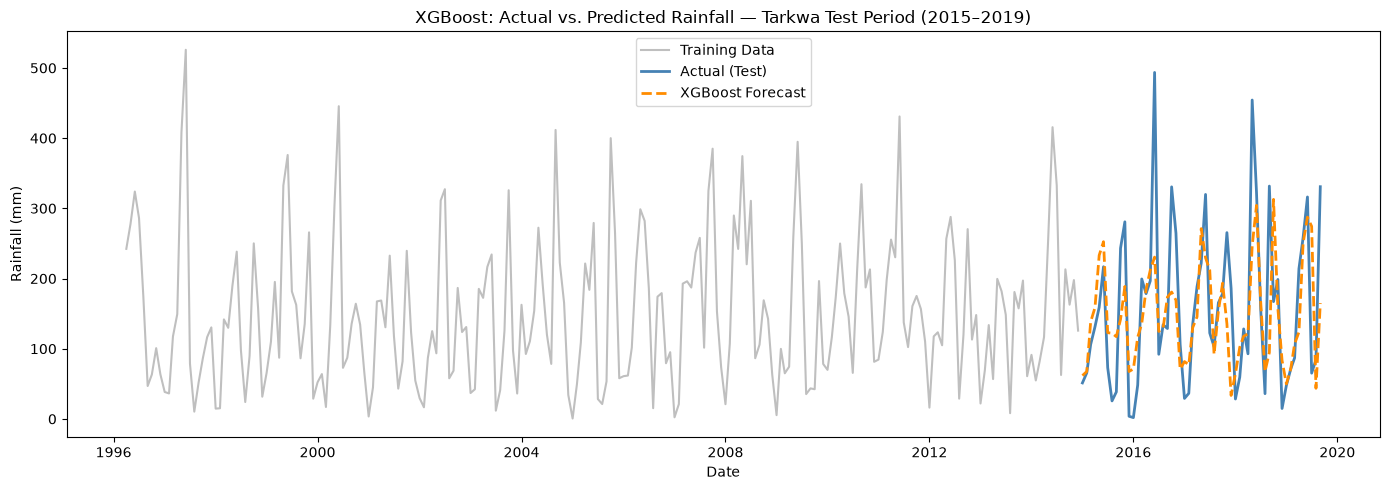

In [4]:
import matplotlib.pyplot as plt

test_dates = df_lagged["Date"].iloc[split_idx:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(df_lagged["Date"].iloc[:split_idx], y_train, label="Training Data", color="gray", alpha=0.5)
plt.plot(test_dates, y_test, label="Actual (Test)", color="steelblue", linewidth=2)
plt.plot(test_dates, y_pred, label="XGBoost Forecast", color="darkorange", linewidth=2, linestyle="--")

plt.title("XGBoost: Actual vs. Predicted Rainfall — Tarkwa Test Period (2015–2019)")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.savefig("../models/xgboost_actual_vs_predicted.png", dpi=150)
plt.show()

In [5]:
import joblib

MODEL_PATH = "../models/xgboost_model.pkl"
joblib.dump(xgb_model, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

# Reload check
loaded_xgb = joblib.load(MODEL_PATH)
test_pred = loaded_xgb.predict(X_test[:3])
print("\nReload check — first 3 test predictions from loaded model:")
print(test_pred)

Model saved to ../models/xgboost_model.pkl

Reload check — first 3 test predictions from loaded model:
[ 61.739365  67.498955 138.33295 ]
